In [1]:
import polars as pl
from aeon.classification.convolution_based import RocketClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
)
from aeon.datasets.tsc_datasets import univariate_equal_length
from sklearn.metrics import accuracy_score

from autotsc.models import AutoTSCModel
from autotsc.utils import load_dataset

2025-11-17 09:52:28.377451: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
stats = []
selected_datasets = univariate_equal_length

In [3]:
import ray

ray.shutdown()
ray.init(num_cpus=24)

2025-11-17 09:52:31,343	INFO worker.py:2012 -- Started a local Ray instance.
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.0
Ray version:,2.51.1


In [4]:
def get_model(name):
    if name == "Catch22Classifier":
        return Catch22Classifier(n_jobs=-1)
    elif name == "RocketClassifier":
        return RocketClassifier(n_jobs=-1, n_kernels=1000)
    elif name == "AutoTSCModel-rocket-catch22":
        return AutoTSCModel(
            n_jobs=-1,
            model_types="rocket-catch22",
            verbose=True,
            use_stacking=False,
            use_only_best_model=True,
        )
    elif name == "AutoTSCModel-rocket":
        return AutoTSCModel(
            n_jobs=-1,
            model_types="rocket",
            verbose=True,
            use_stacking=False,
            use_only_best_model=True,
        )
    elif name == "AutoTSCModel-catch22":
        return AutoTSCModel(
            n_jobs=-1,
            model_types="catch22",
            verbose=True,
            use_stacking=False,
            use_only_best_model=True,
        )
    else:
        raise ValueError(f"Unknown model name: {name}")


for dataset in selected_datasets:
    X_train, y_train, X_test, y_test = load_dataset(dataset)

    for model_name in [
        "Catch22Classifier",
        "RocketClassifier",
        "AutoTSCModel-rocket-catch22",
        "AutoTSCModel-rocket",
        "AutoTSCModel-catch22",
    ]:
        try:
            model = get_model(model_name)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            test_acc = accuracy_score(y_test, pred)
            stats.append(
                {
                    "dataset": dataset,
                    "model": model_name,
                    "test_accuracy": test_acc,
                }
            )
        except Exception as e:
            print(f"Error with dataset {dataset}: {e}")

Error with dataset ACSF1: n_splits=12 cannot be greater than the number of members in each class.
Error with dataset ACSF1: n_splits=12 cannot be greater than the number of members in each class.
Error with dataset ACSF1: n_splits=12 cannot be greater than the number of members in each class.


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=12.
  warnings.warn(


|------------------------|
| Number of samples: 390 |
| Number of channels: 1  |
| Length of series: 176  |
| Number of classes: 37  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7590, time: 0.38s
Model 1 fitted, accuracy: 0.6872, time: 0.45s
Best model: 0 with accuracy 0.7590
9999999 [0]


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=12.
  warnings.warn(


|------------------------|
| Number of samples: 390 |
| Number of channels: 1  |
| Length of series: 176  |
| Number of classes: 37  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7615, time: 0.36s
Best model: 0 with accuracy 0.7615
9999999 [0]


...

|------------------------|
| Number of samples: 267 |
| Number of channels: 1  |
| Length of series: 270  |
| Number of classes: 25  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7041, time: 0.34s
Model 1 fitted, accuracy: 0.5506, time: 0.39s
Best model: 0 with accuracy 0.7041
9999999 [0]


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=12.
  warnings.warn(


|------------------------|
| Number of samples: 267 |
| Number of channels: 1  |
| Length of series: 270  |
| Number of classes: 25  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7228, time: 0.33s
Best model: 0 with accuracy 0.7228
9999999 [0]


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=12.
  warnings.warn(


|------------------------|
| Number of samples: 267 |
| Number of channels: 1  |
| Length of series: 270  |
| Number of classes: 25  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.5506, time: 0.38s
Best model: 0 with accuracy 0.5506
9999999 [0]
|------------------------|
| Number of samples: 181 |
| Number of channels: 1  |
| Length of series: 900  |
| Number of classes: 5   |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7403, time: 0.56s
Model 1 fitted, accuracy: 0.7017, time: 0.41s
Best model: 0 with accuracy 0.7403
9999999 [0]
|------------------------|
| Number of samples: 181 |
| Number of channels: 1  |
| Length of series: 900  |
| Number of classes: 5   |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7072, time: 0.56s
Best model: 0 with accuracy 0.7072
9999999 [0]
|------------------------|


In [5]:
stats = pl.DataFrame(stats)
stats

dataset,model,test_accuracy
str,str,f64
"""ACSF1""","""Catch22Classifier""",0.85
"""ACSF1""","""RocketClassifier""",0.85
"""Adiac""","""Catch22Classifier""",0.713555
"""Adiac""","""RocketClassifier""",0.746803
"""Adiac""","""AutoTSCModel-rocket-catch22""",0.764706
…,…,…
"""Yoga""","""Catch22Classifier""",0.765333
"""Yoga""","""RocketClassifier""",0.889667
"""Yoga""","""AutoTSCModel-rocket-catch22""",0.890667


In [6]:
stats_pivot = stats.pivot(values="test_accuracy", index="dataset", columns="model").drop_nulls()
stats_pivot

/tmp/ipykernel_639705/4014597102.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  stats_pivot = stats.pivot(values="test_accuracy", index="dataset", columns="model").drop_nulls()


dataset,Catch22Classifier,RocketClassifier,AutoTSCModel-rocket-catch22,AutoTSCModel-rocket,AutoTSCModel-catch22
str,f64,f64,f64,f64,f64
"""Adiac""",0.713555,0.746803,0.764706,0.764706,0.700767
"""ArrowHead""",0.742857,0.834286,0.788571,0.794286,0.731429
"""Car""",0.75,0.916667,0.916667,0.9,0.75
"""CBF""",0.951111,1.0,1.0,1.0,0.961111
"""ChlorineConcentration""",0.589323,0.6796875,0.684375,0.695573,0.588281
…,…,…,…,…,…
"""Wine""",0.481481,0.777778,0.759259,0.759259,0.462963
"""WordSynonyms""",0.529781,0.727273,0.73511,0.73511,0.534483
"""Worms""",0.727273,0.701299,0.74026,0.74026,0.714286


In [7]:
models = stats["model"].unique().to_list()
P = stats_pivot.select(models).to_numpy()

(<Figure size 600x240 with 1 Axes>, <Axes: >)

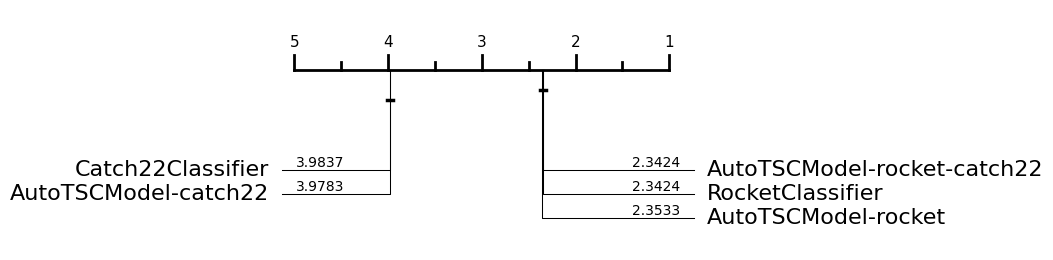

(raylet) [2025-11-17 11:16:31,409 E 639930 639930] (raylet) node_manager.cc:3252: 3 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 219263ecb874a55a4dcb3eaf5a89d59214c16ac587baef8ea8ba23c1, IP: 192.168.3.3) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 192.168.3.3`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.
(raylet) 
(raylet) [2025-11-17 11:17:32,141 E 639930 639930] (raylet) node_manager.cc:3252: 3 Workers (tasks / actors

In [8]:
from aeon.visualisation import plot_critical_difference

plot_critical_difference(P, models)